# Deterministic and stochastic SIR: why chance matters

Let's start with a question: **if one infected person enters a population, will an epidemic definitely take off?**

We will compare two versions of the same SIR model, using the same parameters and initial conditions. Only the way we calculate infections and recoveries will change.

The numbers are chosen to illustrate how the model works, not to describe a particular disease.

Run the cells from top to bottom. You only need NumPy and Matplotlib.

## 1. SIR model

The model divides the population into three groups:

- **S**: susceptible people, who can become infected;
- **I**: infected people, who can transmit the infection;
- **R**: recovered people, who are assumed to be immune.

The population is closed: there are no births, deaths or new arrivals. People mix uniformly.

Each time step is one day. `beta` controls transmission and `mu` controls recovery. We use `beta * I / N` as the daily probability of infection and `mu` as the daily probability of recovery. This is a simple discrete-time approximation: both probabilities must stay between 0 and 1. Our chosen parameters ensure this.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000        # total population
I0 = 1          # start with one infected person
beta = 0.3      # transmission parameter
mu = 0.2        # daily probability of recovery
T = 500         # days to simulate

days = np.arange(T + 1)

## 2. Start with the deterministic model

Each day we calculate:

$$\text{new infections} = S\,\beta\frac{I}{N}$$
$$\text{new recoveries} = I\,\mu$$

These are **expected counts**, given the current values of S and I. For example, with 10 infected people and `mu = 0.2`, the model calculates 2 recoveries. With just one infected person, it calculates 0.2 recoveries: the quantities are continuous, rather than counts of individual people.

In our example, the initial expected number of new infections is about 0.3 and the expected number of recoveries is 0.2. So the number of infected people initially increases.

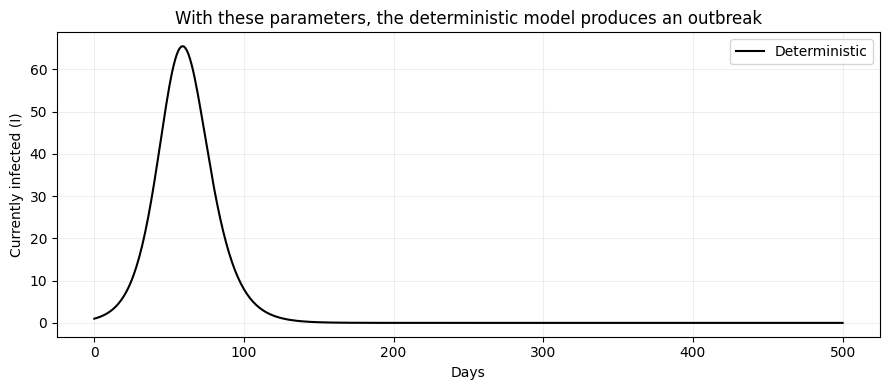

In [2]:
S_det = [N - I0]
I_det = [I0]
R_det = [0]

for t in range(T):
    new_infections = S_det[t] * beta * I_det[t] / N
    new_recoveries = I_det[t] * mu

    S_det.append(S_det[t] - new_infections)
    I_det.append(I_det[t] + new_infections - new_recoveries)
    R_det.append(R_det[t] + new_recoveries)

plt.figure(figsize=(9, 4))
plt.plot(days, I_det, color="black", label="Deterministic")
plt.xlabel("Days")
plt.ylabel("Currently infected (I)")
plt.title("With these parameters, the deterministic model produces an outbreak")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Now allow for chance

In the stochastic model, each susceptible person may or may not become infected, and each infected person may or may not recover. We use the binomial distribution to count how many events happen.

`np.random.binomial(10, 0.2)` asks: among 10 people, each with a 0.2 probability of recovery, how many recover? The result is an integer. Its expected value is 2, but the result does not have to be 2.

**We keep the same parameters and draw the actual counts at random.** For a given state S, I, the expected numbers of infections and recoveries are the same as in the deterministic model.

The `seed` makes the random draws reproducible. Here we use seed 7, an example in which an outbreak takes off, so we can compare the two curves. This example is deliberately selected for illustration; it does not tell us how likely an outbreak is.

We draw the stochastic counts as steps because they are whole numbers updated once a day. The right-hand panel zooms in on the first 30 days, with daily counts marked by dots.

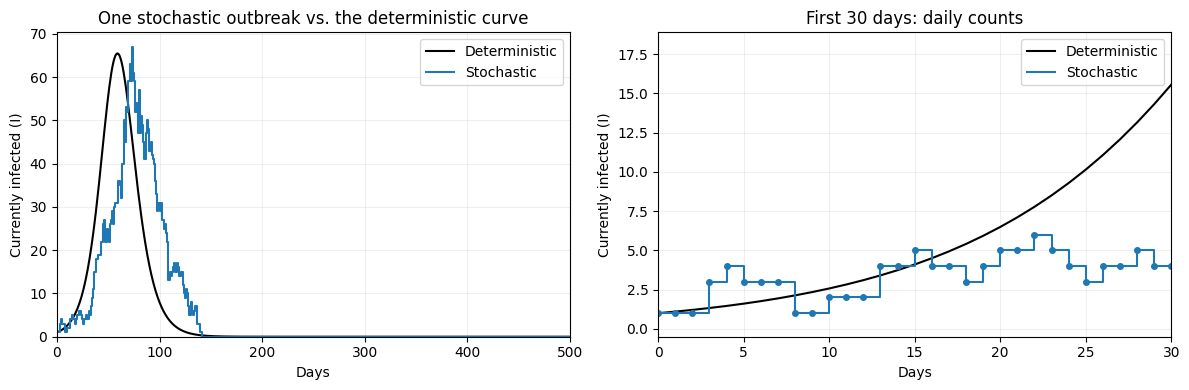

In [5]:
np.random.seed(7)    # try 1 to see an outbreak die out without spreading

S_stoch = [N - I0]
I_stoch = [I0]
R_stoch = [0]

for t in range(T):
    infection_probability = beta * I_stoch[t] / N
    new_infections = np.random.binomial(S_stoch[t], infection_probability)
    new_recoveries = np.random.binomial(I_stoch[t], mu)

    S_stoch.append(S_stoch[t] - new_infections)
    I_stoch.append(I_stoch[t] + new_infections - new_recoveries)
    R_stoch.append(R_stoch[t] + new_recoveries)

# Keep simulating until T. Once I reaches zero, it stays zero.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    ax.plot(days, I_det, color="black", label="Deterministic")
    ax.step(days, I_stoch, where="post", color="tab:blue", label="Stochastic")
    ax.set_xlabel("Days")
    ax.set_ylabel("Currently infected (I)")
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_title("One stochastic outbreak vs. the deterministic curve")
axes[0].set_xlim(0, T)
axes[0].set_ylim(bottom=0)

axes[1].set_title("First 30 days: daily counts")
axes[1].plot(days[:31], I_stoch[:31], "o", color="tab:blue", markersize=4)
axes[1].set_xlim(0, 30)
zoom_max = max(max(I_det[:31]), max(I_stoch[:31]))
axes[1].set_ylim(-0.5, zoom_max * 1.15 + 1)
plt.tight_layout()
plt.show()

With seed 7 and the starting parameters, both models produce an outbreak, but the stochastic curve fluctuates and follows its own timing. The small steps are changes in the number of infected people, not a plotting error.

Try seed 1 instead: the initial infected person recovers without infecting anyone else. The stochastic count then stays at zero. A flat line at zero is a valid outcome: without infected people or new arrivals, transmission cannot restart.

**Expected growth does not guarantee growth in every outbreak.** One simulation shows one possible story. We need repeated simulations to find out how often different outcomes occur.

## 4. Repeat the same experiment 100 times

Imagine 100 identical populations, each starting with one infected person. The parameters stay the same. Only the random draws change.

The code inside the loop is the same as before. We simply add an outer loop to repeat the simulation. Set the seed **once, before the loop**: resetting it to the same value inside the loop would produce the same story every time.

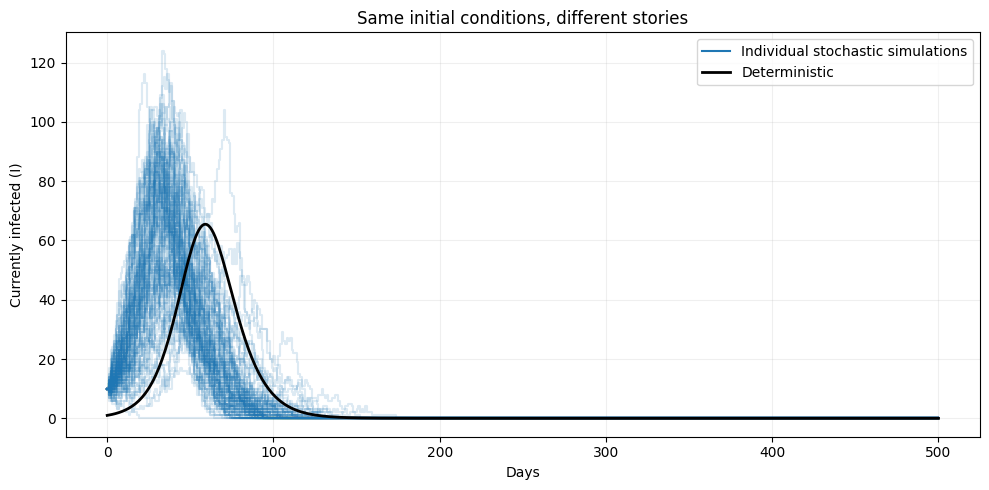

In [8]:
np.random.seed(42)
n_simulations = 100

I_runs = []
total_infected = []
peaks = []

for simulation in range(n_simulations):
    S = [N - I0]
    I = [I0]
    R = [0]

    for t in range(T):
        infection_probability = beta * I[t] / N
        new_infections = np.random.binomial(S[t], infection_probability)
        new_recoveries = np.random.binomial(I[t], mu)

        S.append(S[t] - new_infections)
        I.append(I[t] + new_infections - new_recoveries)
        R.append(R[t] + new_recoveries)

    I_runs.append(I)
    total_infected.append(N - S[-1])
    peaks.append(max(I))

plt.figure(figsize=(10, 5))
for I in I_runs:
    plt.step(days, I, where="post", color="tab:blue", alpha=0.15)

# An empty line adds a single entry to the legend.
plt.plot([], [], color="tab:blue", label="Individual stochastic simulations")
plt.plot(days, I_det, color="black", linewidth=2, label="Deterministic")
plt.xlabel("Days")
plt.ylabel("Currently infected (I)")
plt.title("Same initial conditions, different stories")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Before moving on, look at the plot:

1. Does every simulation produce a large outbreak?
2. When an outbreak takes off, does the peak always occur on the same day?
3. Is the maximum number of infected people always the same?

The curves near zero represent outbreaks that died out after few infections. The other curves differ in height and timing. The deterministic model gives a single trajectory.

## 5. How many people were infected in total?

So far we have plotted **I**, the number of people infected on a particular day. Now we look at **N − S**, the number of people who have been infected by the last day, including the initially infected person.

If no infected people remain, this is the final outbreak size. We therefore also check whether any simulations are still active.

Simulations still active on the last day: 0
Simulations with no infections beyond the initial case: 36 out of 100
Total infected in the deterministic model: 590


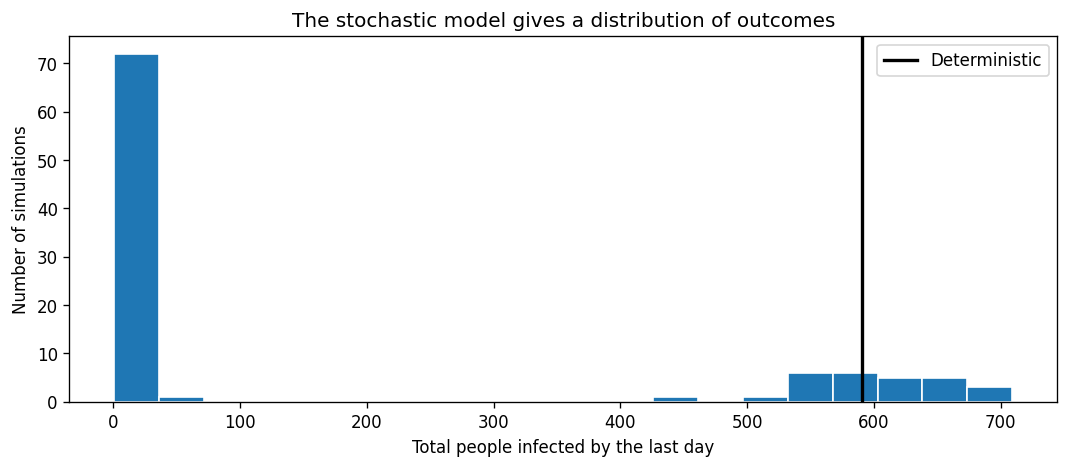

In [5]:
total_det = N - S_det[-1]
still_active = sum(I[-1] > 0 for I in I_runs)
no_further_infections = sum(total == I0 for total in total_infected)

print("Simulations still active on the last day:", still_active)
print("Simulations with no infections beyond the initial case:",
      no_further_infections, "out of", n_simulations)
print("Total infected in the deterministic model:", round(total_det))

plt.figure(figsize=(9, 4))
plt.hist(total_infected, bins=20, color="tab:blue", edgecolor="white")
plt.axvline(total_det, color="black", linewidth=2, label="Deterministic")
plt.xlabel("Total people infected by the last day")
plt.ylabel("Number of simulations")
plt.title("The stochastic model gives a distribution of outcomes")
plt.legend()
plt.tight_layout()
plt.show()

The deterministic model gives one number for the total infected. The stochastic model shows **which outcomes can occur and how often they occur in our simulations**.

We can also ask a specific question: how many simulations reached at least 20 infected people at the same time? The threshold of 20 is chosen for this exercise; it is not a universal definition of an epidemic.

In [6]:
threshold = 20
reach_threshold = sum(peak >= threshold for peak in peaks)

print("Simulations reaching at least", threshold, "infected people at the same time:")
print(reach_threshold, "out of", n_simulations)
print("Observed frequency:", round(reach_threshold / n_simulations * 100, 1), "%")

Simulations reaching at least 20 infected people at the same time:
27 out of 100
Observed frequency: 27.0 %


This frequency estimates a probability **within our model and the simulated period**. It can change with the seed; increasing the number of simulations tends to make the estimate more stable. It is not automatically the probability of an epidemic in the real world.

## 6. Two small experiments

**A. Change only the seed in the single stochastic simulation from 7 to 1.** Run that cell again. The outcome changes even though the parameters are identical. With seed 1 and the original parameters, the infection dies out without spreading. The same plotting code works for both outcomes.

**B. Change `I0` from 1 to 20 in the first code cell and rerun all code cells.** Is it still as easy for the infection to die out before a substantial outbreak develops? Are the trajectories more similar?

The total population size is not the only thing that matters: **the number of infected people matters too**. Even in a large population, an infection introduced by a single person can disappear by chance.

## What should we take away?

The stochastic model represents the randomness of individual infections and recoveries. It lets us study variation in outcomes and the possibility that an outbreak dies out early.

The deterministic model is useful for studying the overall dynamics, especially when many people are infected and relative fluctuations are smaller.

One subtle point: the deterministic model uses expected events **at each step**, but its full trajectory is not necessarily the average of the stochastic trajectories. Outbreaks can die out or peak at different times, and transmission depends on the product S × I.

**The key idea:** “It can grow on average” does not mean “it will grow every time”.